# Fractional orbital vs ballistic: three-dimensional rendering

A fractional orbital profile arriving over the southern hemisphere, against
the ballistic alternative between the same two points, rendered on a
ray-traced globe.

## The headline result inverted when the sensor network grew

An earlier version of this analysis, against a thirteen-site network with
**no southern-hemisphere coverage**, found the fractional profile removing
about 24 minutes of warning. The network has since been extended to
twenty-two sites including Exmouth and Cape Town, and the conclusion
reverses: the fractional profile now concedes **more** warning than the
ballistic arc, 47.6 minutes against 29.0.

Section 5 shows that **a single sensor is responsible**. Dropping Exmouth
alone restores the old answer exactly — 4.6 minutes, a 24.4-minute
advantage. Nothing else in the model changed.

The mechanism is worth stating because it separates two things this
analysis had been treating as one. Warning time is measured from *first*
detection to impact, and the fractional profile flies for 69 minutes against
the ballistic arc's 30. Being seen by **few** sensors and being seen **late**
are different properties, and only the second buys warning:

- **Azimuth denial still holds decisively.** The fractional profile is seen
  by 2 sites; the ballistic arc by 10.
- **Warning advantage does not.** One southern sensor picking it up early
  means it is then tracked for the remaining three quarters of a much
  longer flight.

So the profile's advantage was never robust — it was contingent on a
coverage gap, and a single station closes it.

## What changed, and why

The previous version drew the Earth with Matplotlib's `plot_surface` and a
texture passed as `facecolors`. That fills **each mesh quad with one flat
colour**, so the visible resolution is the mesh's, not the texture's: a
4096x2048 Blue Marble downsampled onto a 256x128 mesh discards 99.6 % of its
pixels and leaves facets along every coastline. Raising the mesh resolution
costs quadratically and does not fix the other artefact — Matplotlib sorts
whole artists by depth, so a trajectory passing *behind* the planet is drawn
*in front* of it.

`passes.viz.globe` replaces both. It intersects a camera ray with the sphere
per output pixel and samples the texture bilinearly, so sharpness is limited
by the texture and the frame size and never by a mesh; and it returns a
depth buffer, so occlusion is a per-point test rather than an artist sort.
A 1600x900 frame takes about 0.2 s.

The camera is also no longer `view_init(elev, azim)` on a fixed box. It is a
pinhole camera with a position, a look-at target and a field of view, driven
by a chase rig that sits behind and above the vehicle along its own velocity
— which is what makes a hypersonic trajectory followable rather than a line
sweeping across a static globe.

## 1. Scenario

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from passes.geodesy import GeodeticPosition, great_circle_range, WGS84_MEAN_RADIUS
from passes.orbital.radar import EARLY_WARNING_SITES, coverage
from passes.orbital.scenario import warning_comparison
from passes.viz import Camera, load_texture, look_at, project, render, sun_direction

R = WGS84_MEAN_RADIUS

LAUNCH = GeodeticPosition.from_degrees(51.0, 59.0, 120.0, "Dombarovskiy")
TARGET = GeodeticPosition.from_degrees(38.87, -77.06, 24.0, "aimpoint")
PARKING_ALTITUDE = 150e3
SAMPLES = 900

texture = load_texture()

comparison = warning_comparison(
    LAUNCH, TARGET,
    parking_altitude=PARKING_ALTITUDE,
    sites=tuple(EARLY_WARNING_SITES),
    samples=SAMPLES,
    earth_rotation=True,
)
ballistic, fobs = comparison.ballistic, comparison.fobs

print(f"separation      {great_circle_range(LAUNCH, TARGET)/1e3:,.0f} km")
print(f"{'':16}{'ballistic':>12}{'fractional':>12}")
print(f"{'apogee (km)':16}{ballistic.apogee/1e3:12,.0f}{fobs.apogee/1e3:12,.0f}")
print(f"{'flight (min)':16}{ballistic.flight_time/60:12.1f}{fobs.flight_time/60:12.1f}")
print(f"{'warning (min)':16}"
      f"{comparison.ballistic_coverage.warning_time/60:12.1f}"
      f"{comparison.fobs_coverage.warning_time/60:12.1f}")
print(f"{'sites':16}{len(comparison.ballistic_coverage.detecting_sites):12d}"
      f"{len(comparison.fobs_coverage.detecting_sites):12d}")

# Place the sun over the middle of the fractional route rather than picking a
# longitude by hand. The route runs over the southern hemisphere, and a
# hand-set subsolar point left most of the chase over unlit Antarctica —
# correct, and unreadable. Deriving it from the trajectory keeps the corridor
# lit for any scenario, which is the property that actually matters.
_mid = comparison.fobs.subpoints[len(comparison.fobs.subpoints) // 2]
SUN = sun_direction(_mid.longitude, np.clip(_mid.latitude, -np.pi / 6, np.pi / 6))
print(f"\nsubsolar point set to {np.rad2deg(_mid.longitude):+.0f} lon, "
      f"{np.rad2deg(np.clip(_mid.latitude, -np.pi/6, np.pi/6)):+.0f} lat "
      "(mid-route, so the corridor is lit)")

separation      9,146 km
                   ballistic  fractional
apogee (km)            1,301         150
flight (min)            29.8        69.0
warning (min)           29.0        47.6
sites                     10           2

subsolar point set to +161 lon, -30 lat (mid-route, so the corridor is lit)


## 2. Scene helpers

In [2]:
def ecef(position, lift=0.0):
    # Geodetic position to a Cartesian vector, optionally lifted clear of
    # the surface so a marker is not half-buried in it.
    radius = R + max(getattr(position, "altitude", 0.0), 0.0) + lift
    return radius * np.array([
        np.cos(position.latitude) * np.cos(position.longitude),
        np.cos(position.latitude) * np.sin(position.longitude),
        np.sin(position.latitude),
    ])


def track_points(trajectory):
    # Trajectory sub-points carry ground position; altitude is separate.
    return np.array([
        (R + alt) * np.array([
            np.cos(p.latitude) * np.cos(p.longitude),
            np.cos(p.latitude) * np.sin(p.longitude),
            np.sin(p.latitude),
        ])
        for p, alt in zip(trajectory.subpoints, trajectory.altitudes)
    ])


def starfield(width, height, density=0.00035, seed=7):
    # A faint, fixed starfield. Deterministic so frames do not shimmer.
    rng = np.random.default_rng(seed)
    sky = np.zeros((height, width, 3))
    count = int(width * height * density)
    ys = rng.integers(0, height, count)
    xs = rng.integers(0, width, count)
    magnitude = rng.power(0.35, count)
    tint = 0.75 + 0.25 * rng.random((count, 3))
    sky[ys, xs] = (magnitude[:, None] * tint)
    return sky


def draw_track(ax, points, camera, color, width=2.0, alpha=1.0, zorder=3):
    # Occluded samples become NaN, which breaks the polyline exactly where
    # the globe cuts in front of it.
    px, py, visible = project(points, camera, radius=R)
    ax.plot(np.where(visible, px, np.nan), np.where(visible, py, np.nan),
            color=color, linewidth=width, alpha=alpha, zorder=zorder,
            solid_capstyle="round")


def draw_marker(ax, position, camera, **kwargs):
    px, py, visible = project(np.atleast_2d(position), camera, radius=R)
    if visible[0]:
        ax.scatter(px[0], py[0], **kwargs)
        return True
    return False


def new_frame(camera, sun=SUN, ambient=0.13, atmosphere=0.6, night=0.20):
    # Render the globe over a starfield and return an axes in pixel space,
    # so every overlay is drawn in the same coordinates the globe was.
    # Specular kept low: at globe scale a broad ocean highlight reads as a
    # smudge rather than as sun glint, and it competes with the tracks.
    image, _ = render(camera, texture, R, sun=sun, ambient=ambient,
                      atmosphere=atmosphere, specular=0.10, night=night,
                      background=starfield(camera.width, camera.height))
    fig, ax = plt.subplots(figsize=(camera.width / 100, camera.height / 100), dpi=100)
    fig.patch.set_facecolor("black")
    ax.imshow(np.clip(image, 0, 1), interpolation="bilinear", zorder=0)
    ax.set_xlim(0, camera.width); ax.set_ylim(camera.height, 0)
    ax.axis("off")
    fig.subplots_adjust(0, 0, 1, 1)
    return fig, ax


BALLISTIC_COLOR = "#5AA9FF"
FOBS_COLOR = "#FF8A3D"
ENTRY_COLOR = "#FF3B30"

ballistic_pts = track_points(ballistic)
fobs_pts = track_points(fobs)
launch_ecef = ecef(LAUNCH, lift=20e3)
target_ecef = ecef(TARGET, lift=20e3)
print(f"tracks: ballistic {ballistic_pts.shape}, fractional {fobs_pts.shape}")

tracks: ballistic (900, 3), fractional (900, 3)


## 3. Establishing shot

Both profiles at once. The fractional track disappears behind the limb for
most of its flight — that occlusion is the depth test working, and it is
also the argument: the vehicle is below the horizon of everything on this
face of the planet.

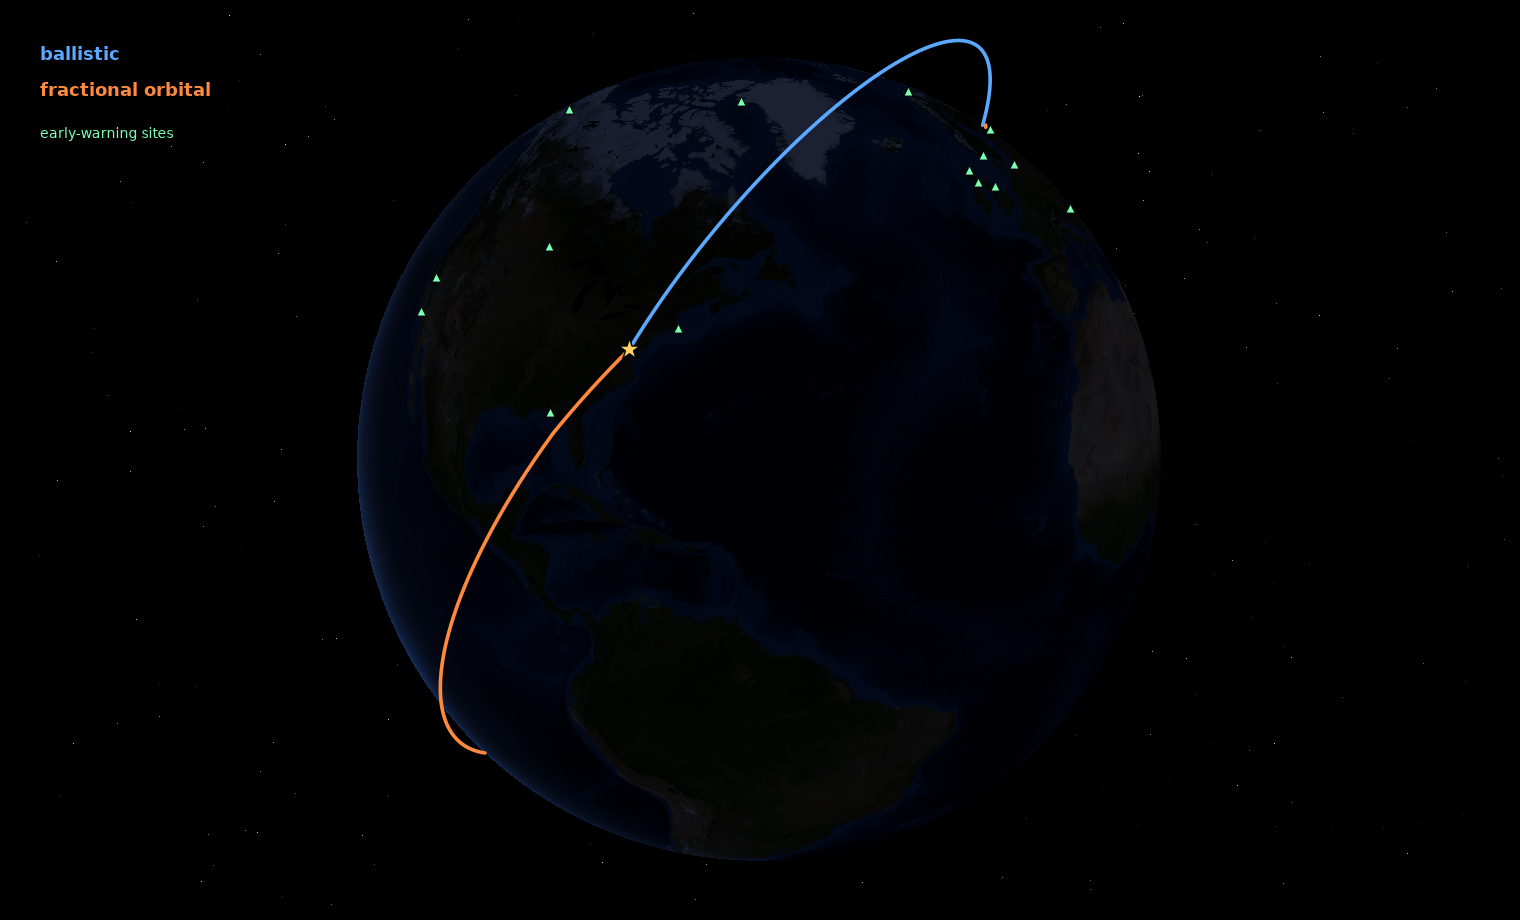

In [3]:
mid = 0.5 * (launch_ecef + target_ecef)
camera = look_at(np.zeros(3), 3.4 * R,
                 azimuth=np.arctan2(mid[1], mid[0]) - np.deg2rad(35),
                 elevation=np.deg2rad(28),
                 fov=np.deg2rad(38), width=1500, height=900)

fig, ax = new_frame(camera)
draw_track(ax, ballistic_pts, camera, BALLISTIC_COLOR, 2.6)
draw_track(ax, fobs_pts, camera, FOBS_COLOR, 2.6)
draw_marker(ax, launch_ecef, camera, s=130, marker="v", c="white",
            edgecolors="black", linewidths=1.2, zorder=6)
draw_marker(ax, target_ecef, camera, s=260, marker="*", c="#FFD166",
            edgecolors="black", linewidths=1.0, zorder=6)
for site in EARLY_WARNING_SITES:
    draw_marker(ax, ecef(site.position, lift=15e3), camera, s=42, marker="^",
                c="#7CFFB2", edgecolors="black", linewidths=0.6, zorder=5)

ax.text(0.02, 0.96, "ballistic", transform=ax.transAxes, color=BALLISTIC_COLOR,
        fontsize=13, va="top", weight="bold")
ax.text(0.02, 0.92, "fractional orbital", transform=ax.transAxes, color=FOBS_COLOR,
        fontsize=13, va="top", weight="bold")
ax.text(0.02, 0.87, "early-warning sites", transform=ax.transAxes, color="#7CFFB2",
        fontsize=10, va="top")
plt.show()

## 4. The southern approach

Viewed from below the equator, the fractional track is fully exposed. This
is the view that used to make the case for the profile — a long flight over
a hemisphere with almost no early-warning coverage, arriving on the reversed
bearing.

It is also the view that shows why the case no longer holds. The southern
sensors are sparse but they are **not absent**, and the next section shows
that sparse is not the same as none.

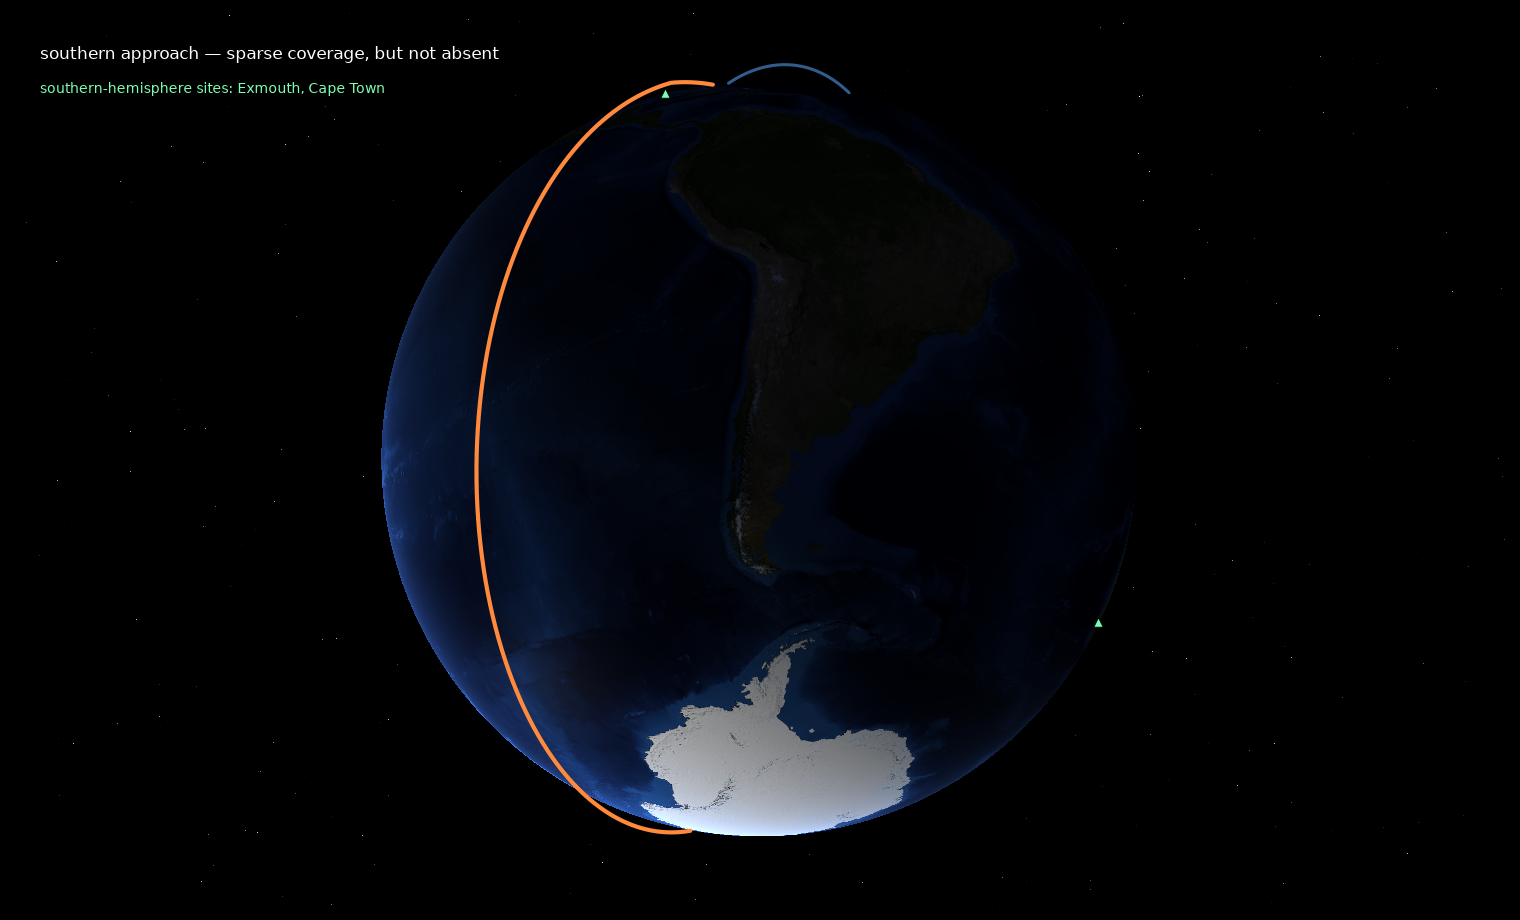

In [4]:
camera_s = look_at(np.zeros(3), 3.6 * R, azimuth=np.deg2rad(-70),
                   elevation=np.deg2rad(-42), fov=np.deg2rad(38),
                   width=1500, height=900)
fig, ax = new_frame(camera_s, ambient=0.14)
draw_track(ax, ballistic_pts, camera_s, BALLISTIC_COLOR, 2.2, alpha=0.55)
draw_track(ax, fobs_pts, camera_s, FOBS_COLOR, 3.0)
for site in EARLY_WARNING_SITES:
    draw_marker(ax, ecef(site.position, lift=15e3), camera_s, s=46, marker="^",
                c="#7CFFB2", edgecolors="black", linewidths=0.6, zorder=5)
draw_marker(ax, target_ecef, camera_s, s=260, marker="*", c="#FFD166",
            edgecolors="black", linewidths=1.0, zorder=6)
southern = [s_ for s_ in EARLY_WARNING_SITES if s_.position.latitude < 0]
ax.text(0.02, 0.96, "southern approach — sparse coverage, but not absent",
        transform=ax.transAxes, color="white", fontsize=12, va="top")
ax.text(0.02, 0.92,
        "southern-hemisphere sites: " + ", ".join(s_.name for s_ in southern),
        transform=ax.transAxes, color="#7CFFB2", fontsize=10, va="top")
plt.show()

## 5. One sensor decides the answer

The advantage the fractional profile is supposed to buy turns on whether
*any* station sees it early. Removing sensors one at a time isolates which.

In [5]:
def warning_for(sites):
    result = warning_comparison(
        LAUNCH, TARGET, parking_altitude=PARKING_ALTITUDE,
        sites=tuple(sites), samples=500, earth_rotation=True,
    )
    ball = result.ballistic_coverage.warning_time / 60
    frac = (result.fobs_coverage.warning_time / 60
            if result.fobs_coverage.detected else float("nan"))
    return ball, frac, result.fobs_coverage


full = list(EARLY_WARNING_SITES)
cases = {
    f"full network ({len(full)} sites)": full,
    "drop southern hemisphere": [s_ for s_ in full if s_.position.latitude >= 0],
    "drop Exmouth only": [s_ for s_ in full if "Exmouth" not in s_.name],
    "drop Cape Town only": [s_ for s_ in full if "Cape Town" not in s_.name],
}
print(f"{'network':30}{'ballistic':>11}{'fractional':>12}{'advantage':>11}  first detector")
for label, subset in cases.items():
    ball, frac, cov = warning_for(subset)
    print(f"{label:30}{ball:11.1f}{frac:12.1f}{ball - frac:+11.1f}  "
          f"{cov.first_detecting_site or 'none'}")
print("\nWarning is measured from FIRST detection to impact, and the fractional")
print("profile flies for 69 min against the ballistic arc's 30. One early")
print("detection therefore costs it more than being seen by ten late ones.")

network                         ballistic  fractional  advantage  first detector
full network (22 sites)              29.0        47.6      -18.6  Exmouth
drop southern hemisphere             29.0         4.6      +24.4  Eglin
drop Exmouth only                    29.0         4.6      +24.4  Eglin
drop Cape Town only                  29.0        47.6      -18.6  Exmouth

Warning is measured from FIRST detection to impact, and the fractional
profile flies for 69 min against the ballistic arc's 30. One early
detection therefore costs it more than being seen by ten late ones.


Dropping **Exmouth alone** restores the entire 24-minute advantage; dropping
Cape Town changes nothing. The result is not a property of southern coverage
in general but of one station that happens to lie under this particular
track.

That fragility is the finding. A conclusion that a single sensor can invert
is not a robust operational advantage, and any warning figure quoted from
this framework should be accompanied by the network it was computed
against.

## 6. Cinematic chase

The camera rides behind and above the vehicle along its own velocity, with
the range easing in as the profile descends. A trailing ribbon marks where
it has been; the ballistic arc is drawn faintly throughout for reference.

`ease` is a smoothstep — linear interpolation between camera states reads as
mechanical, and the acceleration discontinuity at each keyframe is visible.

**The chase is lit from the camera rather than from the sun, and that is a
deliberate cheat.** The route and the aimpoint are half a globe apart, so a
true subsolar point can light the mid-flight leg or the arrival but not
both: with the sun over the mid-route the last five minutes — the part that
matters — play out in deep night. Camera-relative lighting removes the
terminator entirely and keeps the whole run legible. The static frames in
sections 3, 4 and 7 keep a real subsolar point, so the terminator is still
shown where it can be seen properly.

In [6]:
def ease(t):
    t = np.clip(t, 0.0, 1.0)
    return t * t * (3.0 - 2.0 * t)


def chase_camera(points, index, back, lift, fov_deg, width, height, lookahead=6):
    position = points[index]
    ahead = points[min(index + lookahead, len(points) - 1)]
    heading = ahead - position
    norm = np.linalg.norm(heading)
    heading = heading / norm if norm > 1e-6 else position / np.linalg.norm(position)
    up = position / np.linalg.norm(position)
    eye = position - back * heading + lift * up
    return Camera(position=eye, target=position + 0.35 * back * heading,
                  up=up, fov=np.deg2rad(fov_deg), width=width, height=height)


WIDTH, HEIGHT, N_FRAMES = 1280, 720, 150
SKY = starfield(WIDTH, HEIGHT)
step = max(1, len(fobs_pts) // N_FRAMES)

fig = plt.figure(figsize=(WIDTH / 100, HEIGHT / 100), dpi=100)
fig.patch.set_facecolor("black")
ax = fig.add_axes([0, 0, 1, 1]); ax.axis("off")


def draw(frame):
    ax.clear(); ax.axis("off")
    idx = min(frame * step, len(fobs_pts) - 1)
    progress = frame / (N_FRAMES - 1)

    # Pull in and tighten as the vehicle descends.
    back = (1.0 - 0.72 * ease(progress)) * 2.6e6 + 0.4e6
    lift = (1.0 - 0.6 * ease(progress)) * 1.1e6 + 0.15e6
    fov = 44 - 10 * ease(progress)
    camera = chase_camera(fobs_pts, idx, back, lift, fov, WIDTH, HEIGHT)

    # sun=None lights from the camera: no terminator, uniformly readable.
    # See the note above — this is a legibility choice, not a solar model.
    image, _ = render(camera, texture, R, sun=None, ambient=0.30,
                      atmosphere=0.55, specular=0.06, background=SKY)
    ax.imshow(np.clip(image, 0, 1), interpolation="bilinear", zorder=0)
    ax.set_xlim(0, WIDTH); ax.set_ylim(HEIGHT, 0)

    draw_track(ax, ballistic_pts, camera, BALLISTIC_COLOR, 1.6, alpha=0.45)
    draw_track(ax, fobs_pts, camera, FOBS_COLOR, 1.4, alpha=0.30)
    trail = fobs_pts[max(0, idx - 260):idx + 1]
    if len(trail) > 1:
        draw_track(ax, trail, camera, ENTRY_COLOR, 3.2, alpha=0.95, zorder=4)
    draw_marker(ax, fobs_pts[idx], camera, s=90, marker="o", c="white",
                edgecolors=ENTRY_COLOR, linewidths=2.0, zorder=7)
    draw_marker(ax, target_ecef, camera, s=240, marker="*", c="#FFD166",
                edgecolors="black", linewidths=1.0, zorder=6)
    for site in EARLY_WARNING_SITES:
        draw_marker(ax, ecef(site.position, lift=15e3), camera, s=34, marker="^",
                    c="#7CFFB2", edgecolors="black", linewidths=0.5, zorder=5)

    elapsed = fobs.times[idx]
    remaining = fobs.times[-1] - elapsed
    altitude = fobs.altitudes[idx] / 1e3
    ax.text(0.015, 0.965, f"T+{elapsed/60:5.1f} min", transform=ax.transAxes,
            color="white", fontsize=15, va="top", family="monospace")
    ax.text(0.015, 0.915, f"altitude {altitude:6.0f} km", transform=ax.transAxes,
            color="#BFD9FF", fontsize=12, va="top", family="monospace")
    ax.text(0.015, 0.875, f"to impact {remaining/60:5.1f} min", transform=ax.transAxes,
            color="#FFB4A8", fontsize=12, va="top", family="monospace")
    detected = comparison.fobs_coverage.detected and (
        elapsed >= comparison.fobs_coverage.first_detection_time
    )
    ax.text(0.015, 0.835,
            "DETECTED" if detected else "below radar horizon",
            transform=ax.transAxes,
            color="#FF3B30" if detected else "#7CFFB2",
            fontsize=12, va="top", family="monospace", weight="bold")
    return []


anim = FuncAnimation(fig, draw, frames=N_FRAMES, interval=50, blit=False)
anim.save("fobs_chase.gif", writer=PillowWriter(fps=20), dpi=100)
plt.close(fig)
print(f"wrote fobs_chase.gif  ({N_FRAMES} frames, {WIDTH}x{HEIGHT})")

wrote fobs_chase.gif  (150 frames, 1280x720)


## 7. Terminal approach

The last minutes, at the scale where the entry actually happens.

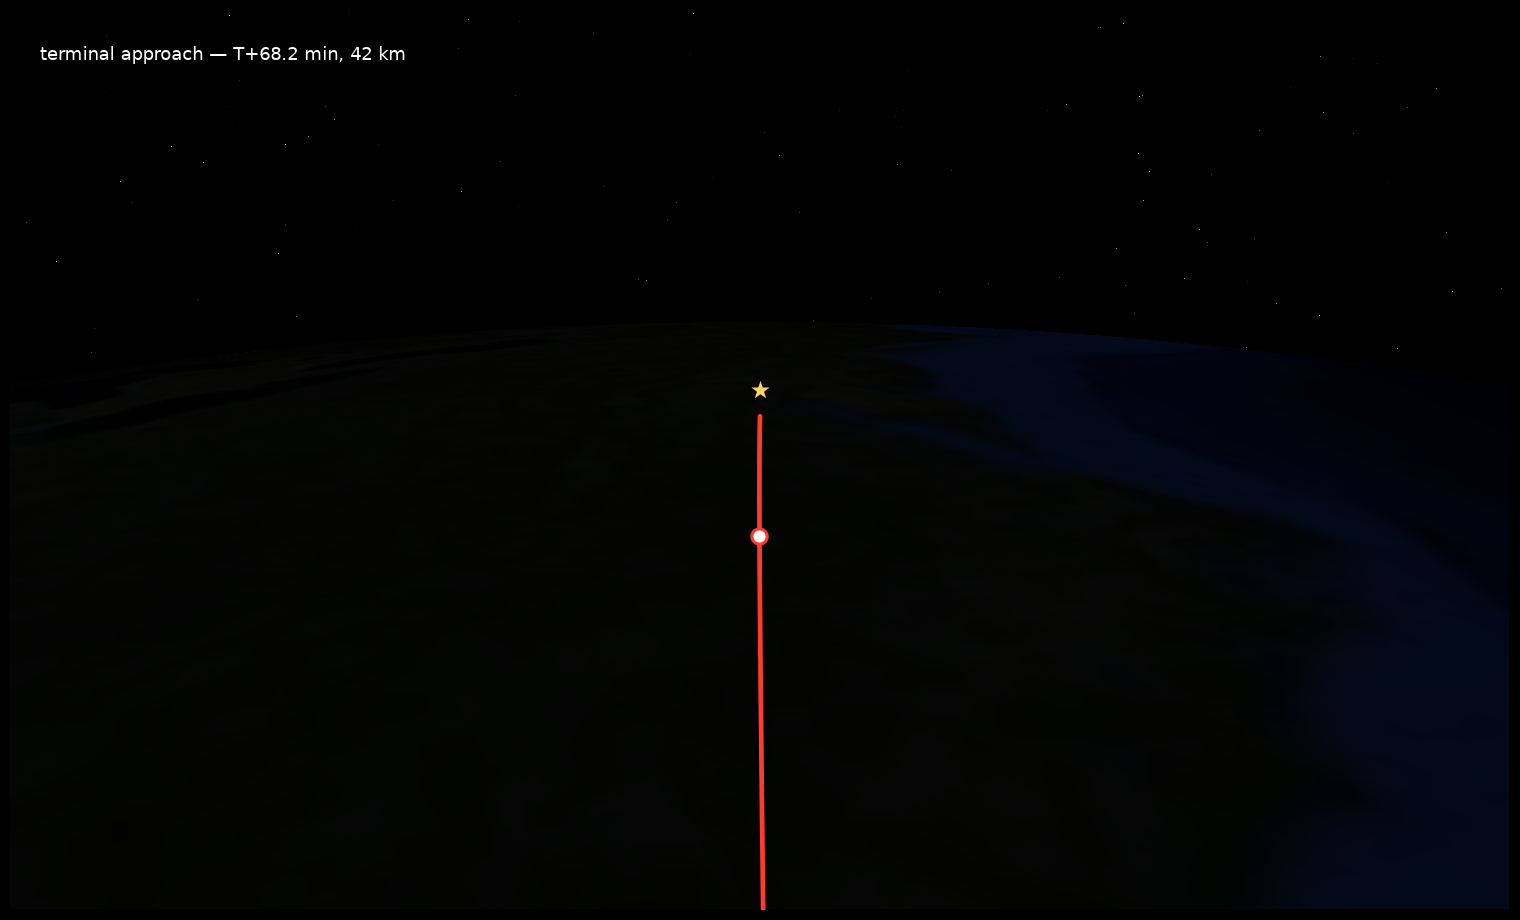

In [7]:
idx = len(fobs_pts) - 12
camera_t = chase_camera(fobs_pts, idx, back=520e3, lift=140e3,
                        fov_deg=40, width=1500, height=900)
fig, ax = new_frame(camera_t, ambient=0.12, atmosphere=0.8)
draw_track(ax, fobs_pts[-400:], camera_t, ENTRY_COLOR, 3.4)
draw_marker(ax, fobs_pts[idx], camera_t, s=120, marker="o", c="white",
            edgecolors=ENTRY_COLOR, linewidths=2.2, zorder=7)
draw_marker(ax, target_ecef, camera_t, s=320, marker="*", c="#FFD166",
            edgecolors="black", linewidths=1.2, zorder=6)
ax.text(0.02, 0.96, f"terminal approach — T+{fobs.times[idx]/60:.1f} min, "
        f"{fobs.altitudes[idx]/1e3:.0f} km",
        transform=ax.transAxes, color="white", fontsize=13, va="top")
plt.show()

## Limitations

The rendering is a presentation layer and is not calibrated against
anything. At close range it also runs out of source: the Blue Marble texture
is 4096x2048, about 11 km per pixel at the equator, so a camera a few hundred
kilometres up magnifies past it and the ground goes soft. That is the
texture's limit, not the renderer's — a higher-resolution image drops
straight in. The shading model — Lambertian terrain, soft terminator, limb
glow, ocean glint — exists so the geometry reads clearly, not to represent
radiance.

The analysis limitations are those of `passes.orbital.scenario` and
`passes.orbital.radar`, and they matter more than the pictures:

- **Geometry only.** Detection is "above the horizon mask", with no
  power-aperture, cross-section, waveform, track-initiation or
  decision-latency model. Warning times are upper bounds.
- **Masks are assumed** at 5 degrees, not published, and the assumption
  binds hardest at exactly the low altitudes a fractional profile uses.
- **No boost-phase infrared.** The largest omission, and it cuts against
  the fractional profile: a longer, higher-energy boost is *more* visible
  from space, well before any ground radar sees the vehicle.
- **The site list is illustrative** and approximate. "No detection" means
  no site *in this list* — not a claim about the world.